  Supply Chain & Delivery Optimisation - Python Analysis
  
  Dataset: supply_chain_orders.csv

In [11]:
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Setting up the global style ----------

sns.set_theme(style="whitegrid", font_scale=1.05)
COLORS = {
    'On Time' : '#2ecc71',
    'Late': '#f39c12',
    'Failed': '#e74c3c',
}
PRIMARY   = '#2c3e50'
ACCENT    = '#2980b9'
HIGHLIGHT = '#e74c3c'


In [5]:
# Load data --------
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Supply chain and delivery optimization\supply_chain_orders.csv", parse_dates=['order_date'])
df.head()

,order_id,order_date,region,warehouse,product_category,units_ordered,unit_cost_gbp,total_order_value_gbp,shipping_mode,promised_delivery_days,actual_delivery_days,delivery_status,return_flag,customer_satisfaction_score,warehouse_utilisation_pct
0,ORD-0001,2023-04-25,Scotland,Warehouse D - Edinburgh,Electronics,5,389.32,1946.60,Standard,5,8,Failed,Y,1,89.6
1,ORD-0002,2023-01-14,North England,Warehouse A - Manchester,Clothing,18,35.88,645.84,Standard,5,5,On Time,N,5,69.2
2,ORD-0003,2023-12-24,London,Warehouse C - London,Electronics,14,222.91,3120.74,Express,2,6,Failed,Y,1,65.4
3,ORD-0004,2023-01-23,North England,Warehouse A - Manchester,Sports & Outdoors,24,102.70,2464.80,Express,2,5,Failed,Y,1,45.6
4,ORD-0005,2023-04-09,Scotland,Warehouse D - Edinburgh,Sports & Outdoors,23,32.52,747.96,Standard,5,7,Late,N,3,89.2


In [6]:
# Derived parameters --------
df['delay_days'] = df['actual_delivery_days'] - df['promised_delivery_days']
df['returned'] = df['return_flag'] == 'Y'
df['revenue_at_risk'] = df.apply(lambda r: r['total_order_value_gbp'] if r['delivery_status'] == 'Failed' else 0, axis=1)

print('=' * 55)
print("  SUPPLY CHAIN & DELIVERY OPTIMISATION ANALYSIS")
print("=" * 55)
print(f"\nTotal Orders      : {len(df):,}")
#print(f'Date Range     : {df['order_date'].min().date()} to {df['order_date'].max().date()}')
print(f"Date Range        : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Total Revenue     : £{df['total_order_value_gbp'].sum():,.0f}")
print(f"On-Time Rate      : {(df['delivery_status']=='On Time').mean() * 100:.1f}%")
print(f"Failed Deliveries : {(df['delivery_status']=='Failed').sum()}")
print(f"Return Rate       : {df['returned'].mean()*100:.1f}%")
print(f"Avg Satisfaction  : {df['customer_satisfaction_score'].mean():.2f} / 5")

  SUPPLY CHAIN & DELIVERY OPTIMISATION ANALYSIS

Total Orders      : 500
Date Range        : 2023-01-01 → 2023-12-30
Total Revenue     : £1,269,691
On-Time Rate      : 57.2%
Failed Deliveries : 67
Return Rate       : 22.6%
Avg Satisfaction  : 3.40 / 5


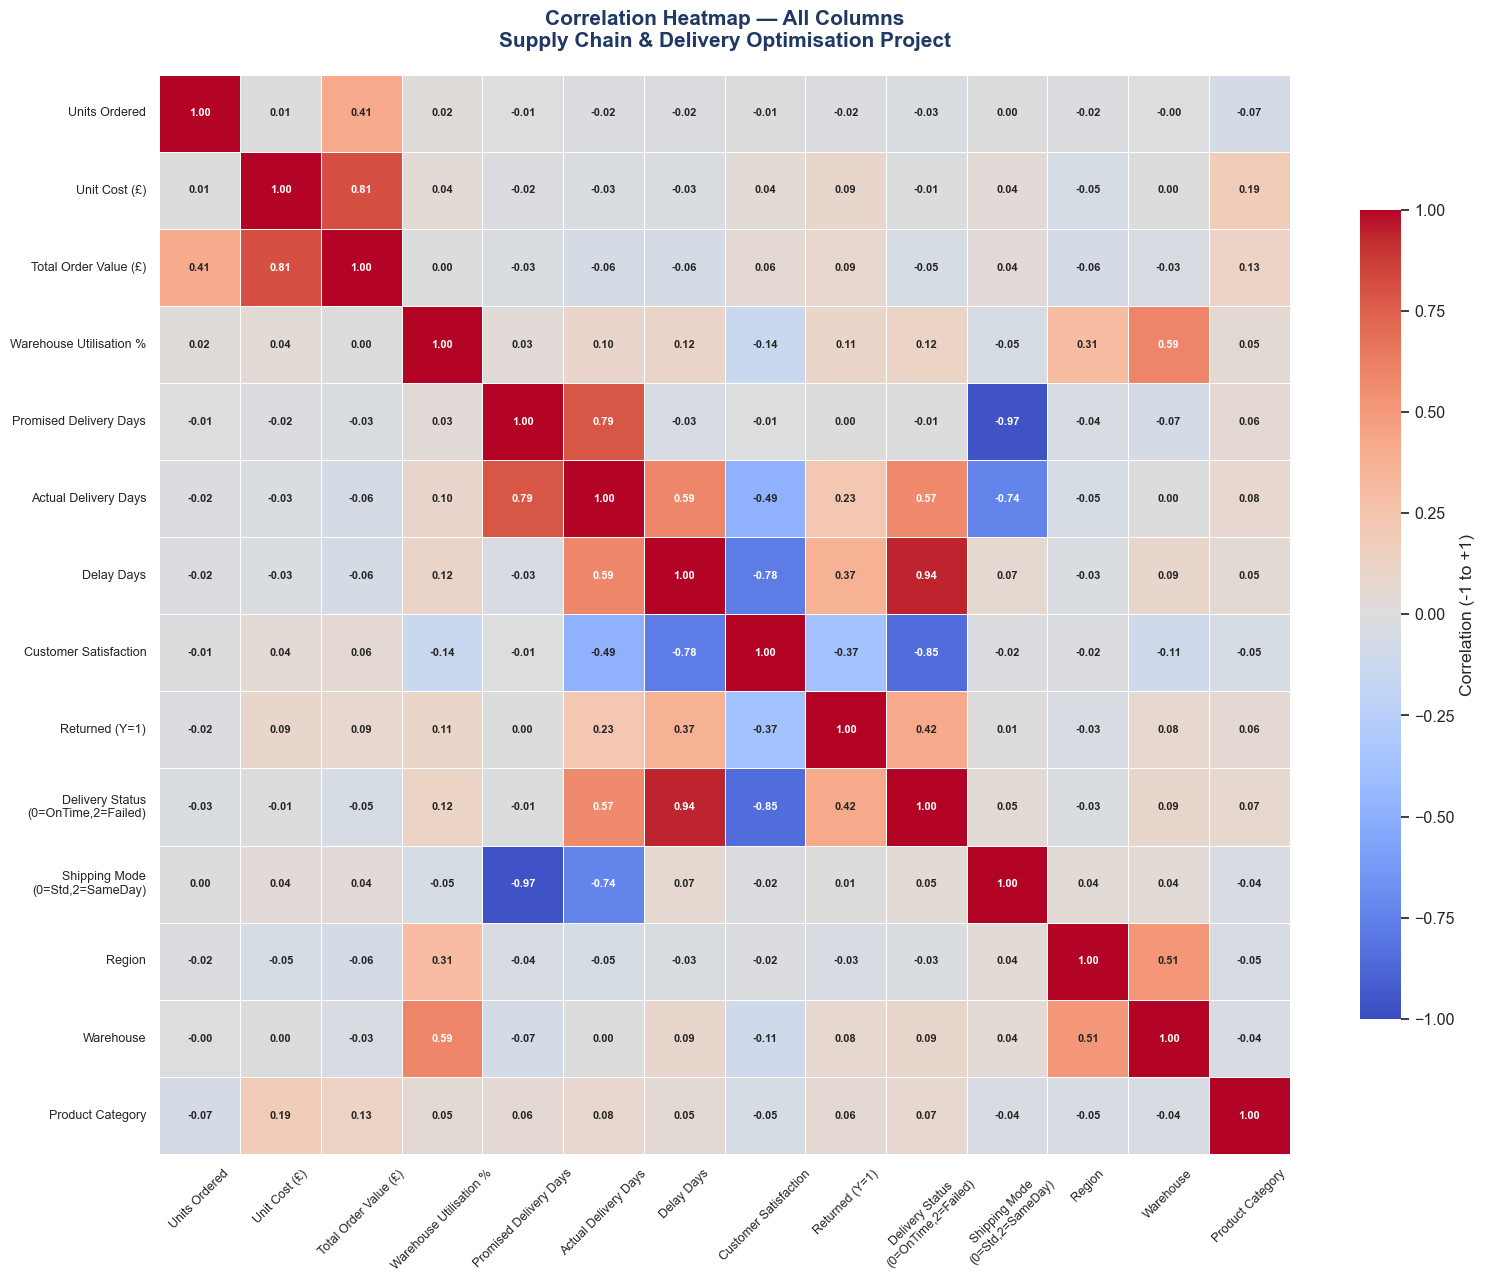

done


In [ ]:
# Encode all columns into numeric so everything can go on the heatmap
corr_df = df.copy()
corr_df['return_flag'] = corr_df['return_flag'].map({'N': 0, 'Y': 1})
for col in ['delivery_status', 'shipping_mode', 'region', 'warehouse', 'product_category']:
    corr_df[col] = corr_df[col].astype('category').cat.codes

corr = corr_df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(16, 13))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    linecolor='white',
    annot_kws={'size': 8, 'weight': 'bold'},
    ax=ax,
    cbar_kws={'shrink': 0.75, 'label': 'Correlation (-1 to +1)'}
)

ax.set_title(
    'Correlation Heatmap — All Columns\nSupply Chain & Delivery Optimisation Project',
    fontsize=15, fontweight='bold', color='#1F3864', pad=20
)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('fig0_correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()
print("done")

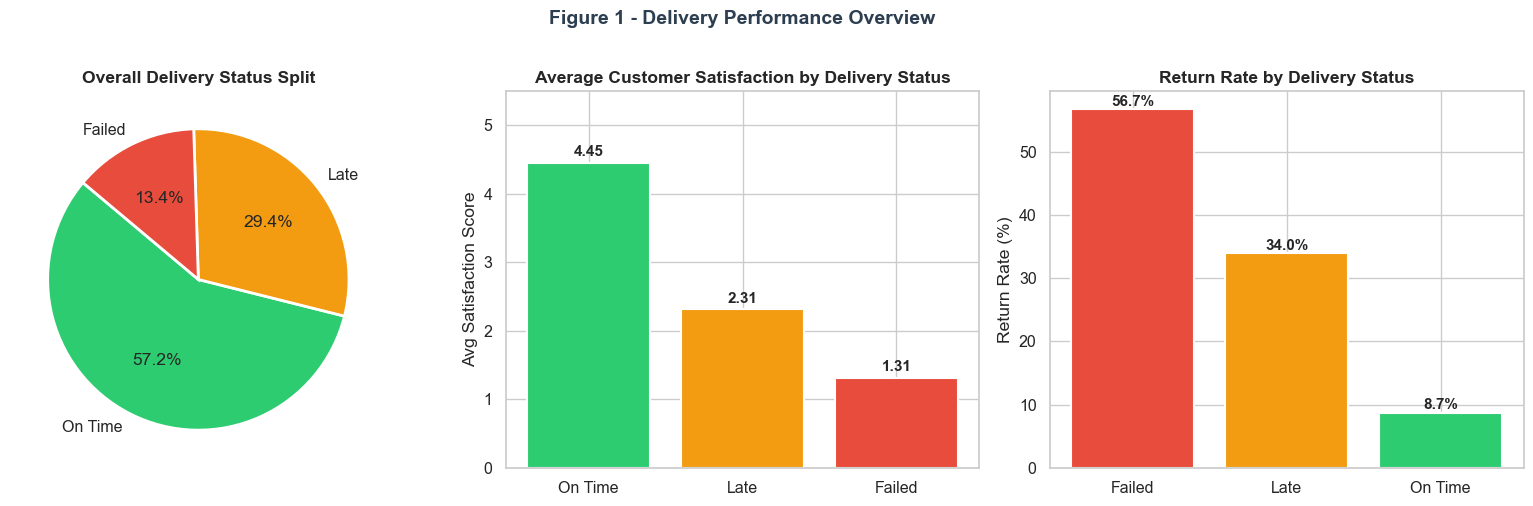

Figure 1 saved : fig1_delivery_overview.png


In [ ]:
# =============================================================
# FIGURE 1 – Delivery Status Overview (KPI summary)
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1 - Delivery Performance Overview', fontsize = 14, fontweight='bold', color = PRIMARY, y=1.01)

# 1a - Pie Chart
status_counts = df['delivery_status'].value_counts()
axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=[COLORS[s] for s in status_counts.index],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Delivery Status Split', fontweight='bold')     


# 1b - Average Satisfaction by status
sat_by_status = df.groupby('delivery_status')['customer_satisfaction_score'].mean().reindex(['On Time', 'Late', 'Failed'])
bars = axes[1].bar(sat_by_status.index, sat_by_status.values, color=[COLORS[s] for s in sat_by_status.index],
                   edgecolor = 'white', linewidth=1.5)
axes[1].set_ylim(0,5.5)
axes[1].set_ylabel('Avg Satisfaction Score')
axes[1].set_title('Average Customer Satisfaction by Delivery Status', fontweight='bold')
for bar, val in zip(bars, sat_by_status.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold', fontsize = 11)


# 1c - Return rate by Status
ret_by_status = df.groupby('delivery_status')['returned'].mean() * 100
bars2 = axes[2].bar(ret_by_status.index, ret_by_status.values, color=[COLORS[s] for s in ret_by_status.index],
                    edgecolor = 'white', linewidth=1.5)
axes[2].set_ylabel('Return Rate (%)')
axes[2].set_title('Return Rate by Delivery Status', fontweight='bold')
for bar, val in zip(bars2, ret_by_status.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize = 11)
plt.tight_layout()
plt.savefig('fig1_delivery_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved : fig1_delivery_overview.png')

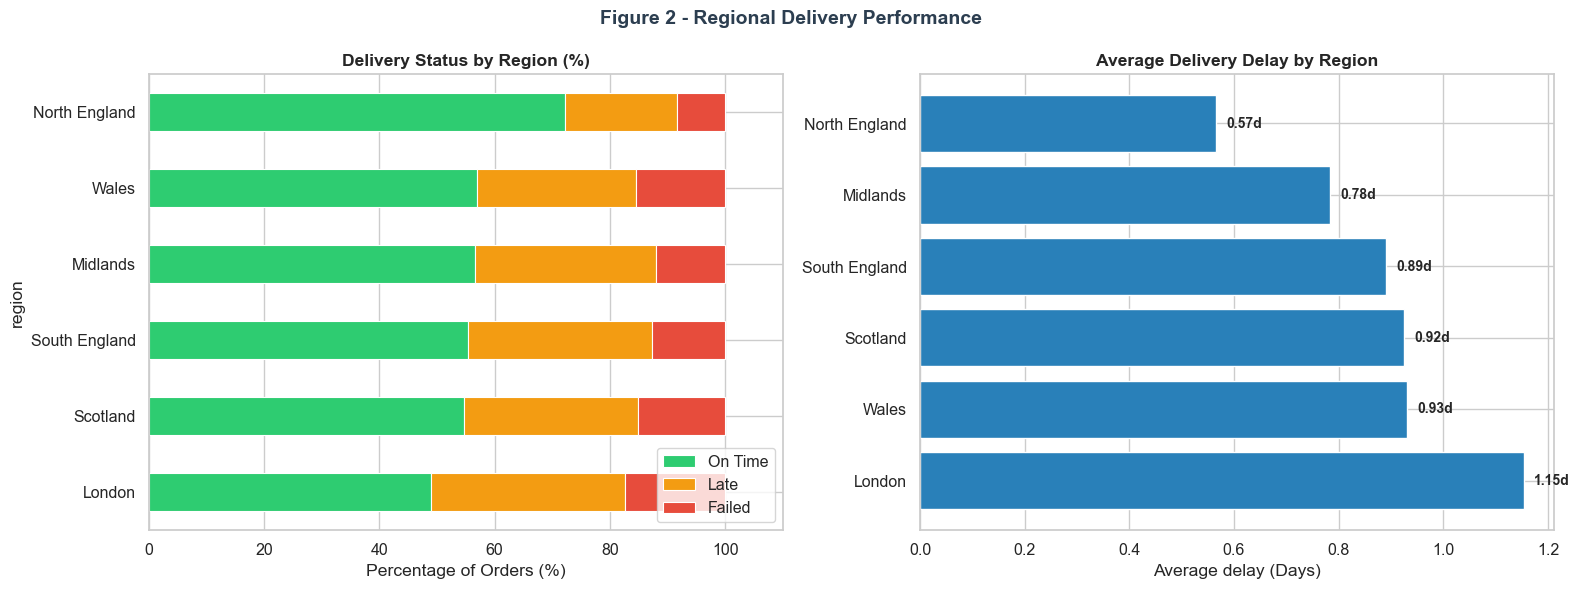

Figure 2 saved : fig2_regional_performance.png


In [7]:
# =============================================================
# FIGURE 2 – Regional Performance
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('Figure 2 - Regional Delivery Performance', fontsize = 14, fontweight='bold', color = PRIMARY)

# 2a - Stacked bar : delivery status by Region
region_status = df.groupby(['region', 'delivery_status']).size().unstack(fill_value=0)
region_status = region_status[['On Time', 'Late', 'Failed']]
region_status_pct = region_status.div(region_status.sum(axis=1), axis=0) * 100
region_status_pct = region_status_pct.sort_values('On Time')
region_status_pct.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=[COLORS['On Time'], COLORS['Late'], COLORS['Failed']],
    edgecolor='white',
    linewidth=0.8 
)
axes[0].set_xlabel('Percentage of Orders (%)')
axes[0].set_title('Delivery Status by Region (%)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim(0,110)

# 2b - Average delay by region
avg_delay = df.groupby('region')['delay_days'].mean().sort_values(ascending=False)
bars = axes[1].barh(avg_delay.index, avg_delay.values, color=ACCENT, edgecolor='white')
axes[1].set_xlabel('Average delay (Days)')
axes[1].set_title('Average Delivery Delay by Region', fontweight = 'bold')
for bar, val in zip (bars, avg_delay.values):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}d', va='center', fontweight='bold', fontsize = 10)
plt.tight_layout()
plt.savefig('fig2_regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved : fig2_regional_performance.png') 

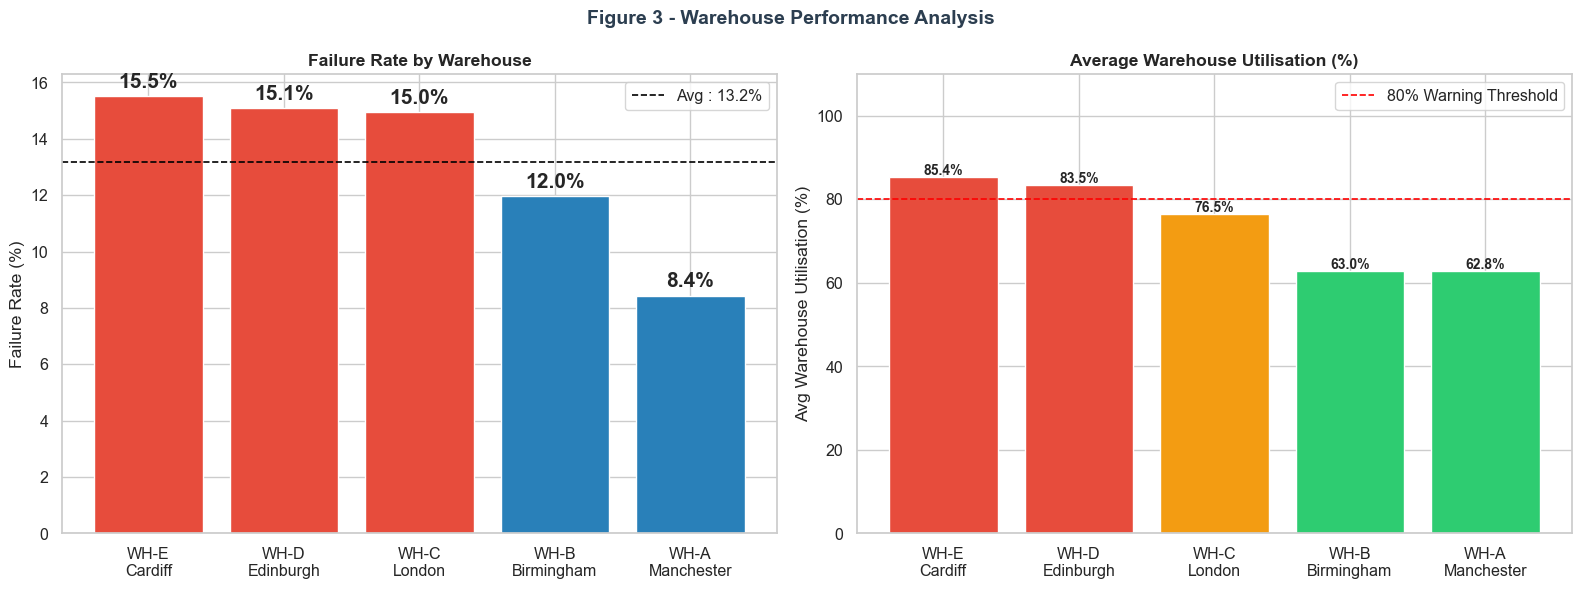

✔ Figure 3 saved: fig3_warehouse_performance.png


In [9]:
# =============================================================
# FIGURE 3 – Warehouse Performance
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 3 - Warehouse Performance Analysis', fontsize = 14, fontweight='bold', color = PRIMARY)

# shorten warehouse names for better visualization
df['wh_short'] = df['warehouse'].str.replace('Warehouse ', 'WH-').str.replace(' - ', '\n')

# 3a - Failure rate by warehouses
fail_rate = df.groupby('wh_short').apply(lambda x: (x['delivery_status'] == 'Failed').mean() * 100).sort_values(ascending=False)
bars = axes[0].bar(fail_rate.index, fail_rate.values, color = [HIGHLIGHT if v > fail_rate.mean() else ACCENT for v in fail_rate.values], edgecolor = 'white')
axes[0].axhline(fail_rate.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Avg : {fail_rate.mean():.1f}%')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].set_title('Failure Rate by Warehouse', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, fail_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize = 15)

# 3b - Avg warehouse utilisation by warehouse
util_avg = df.groupby('wh_short')['warehouse_utilisation_pct'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(util_avg.index, util_avg.values,
                    color=[HIGHLIGHT if v > 80 else '#f39c12' if v > 65 else COLORS['On Time'] for v in util_avg.values],
                    edgecolor='white')
axes[1].axhline(80, color='red', linestyle='--', linewidth=1.2, label='80% Warning Threshold')
axes[1].set_ylabel('Avg Warehouse Utilisation (%)')
axes[1].set_title('Average Warehouse Utilisation (%)', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 110)
for bar, val in zip(bars2, util_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
 
plt.tight_layout()
plt.savefig('fig3_warehouse_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✔ Figure 3 saved: fig3_warehouse_performance.png")

In [ ]:
# =============================================================
# FIGURE 4 – Warehouse Utilisation vs Late/Failed Deliveries
# =============================================================

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Figure 4 - Does high utilization drive late deliveries?', fontsize = 14, fontweight='bold', color=PRIMARY)

scatter_colors = df['delivery_status'].map(COLORS)
scatter = ax.scatter(df['warehouse_utilisation_pct'], df['delay_days'], c=scatter_colors,alpha=0.5,edgecolors='white',linewidth=0.4,s=60)

# Trend Line
z = pd.Series(df['warehouse_utilisation_pct'])
y = pd.Series(df['delay_days'])
m, b = pd.np.polyfit(z, y, 1) if hasattr(pd, 'np') else (__import__('numpy').polyfit(z, y, 1))
x_line = [z.min(), z.max()]
ax.plot(x_line, [m*x + b for x in x_line], color=PRIMARY, linewidth=2, linestyle='--', label='Trend Line')
 
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=COLORS[status], label=status) for status in ['On Time', 'Late', 'Failed']]
legend_patches.append(mpatches.Patch(color=PRIMARY, label='Trend Line'))
ax.legend(handles=legend_patches)
ax.set_xlabel('Warehouse Utilisation (%)')
ax.set_ylabel('Delivery Delay (Days over Promise)')
ax.set_title('Utilisation vs Delay Days', fontweight='bold')
 
plt.tight_layout()
plt.savefig('fig4_utilisation_vs_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Figure 4 saved: fig4_utilisation_vs_delay.png")


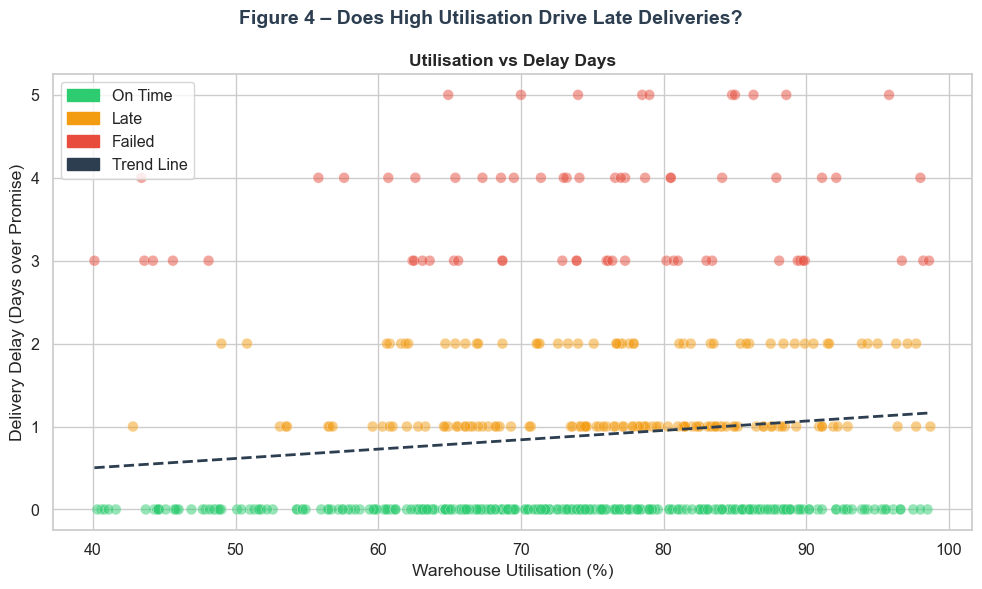

✔ Figure 4 saved: fig4_utilisation_vs_delay.png


In [12]:
# =============================================================
# FIGURE 4 – Warehouse Utilisation vs Late/Failed Deliveries
# =============================================================
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Figure 4 – Does High Utilisation Drive Late Deliveries?', fontsize=14, fontweight='bold', color=PRIMARY)
 
scatter_colors = df['delivery_status'].map(COLORS)
scatter = ax.scatter(
    df['warehouse_utilisation_pct'],
    df['delay_days'],
    c=scatter_colors,
    alpha=0.5, edgecolors='white', linewidth=0.4, s=60
)
 
# Trend line
z = pd.Series(df['warehouse_utilisation_pct'])
y = pd.Series(df['delay_days'])
m, b = pd.np.polyfit(z, y, 1) if hasattr(pd, 'np') else (__import__('numpy').polyfit(z, y, 1))
x_line = [z.min(), z.max()]
ax.plot(x_line, [m*x + b for x in x_line], color=PRIMARY, linewidth=2, linestyle='--', label='Trend Line')
 
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in COLORS.items()]
legend_patches.append(mpatches.Patch(color=PRIMARY, label='Trend Line'))
ax.legend(handles=legend_patches)
ax.set_xlabel('Warehouse Utilisation (%)')
ax.set_ylabel('Delivery Delay (Days over Promise)')
ax.set_title('Utilisation vs Delay Days', fontweight='bold')
 
plt.tight_layout()
plt.savefig('fig4_utilisation_vs_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Figure 4 saved: fig4_utilisation_vs_delay.png")

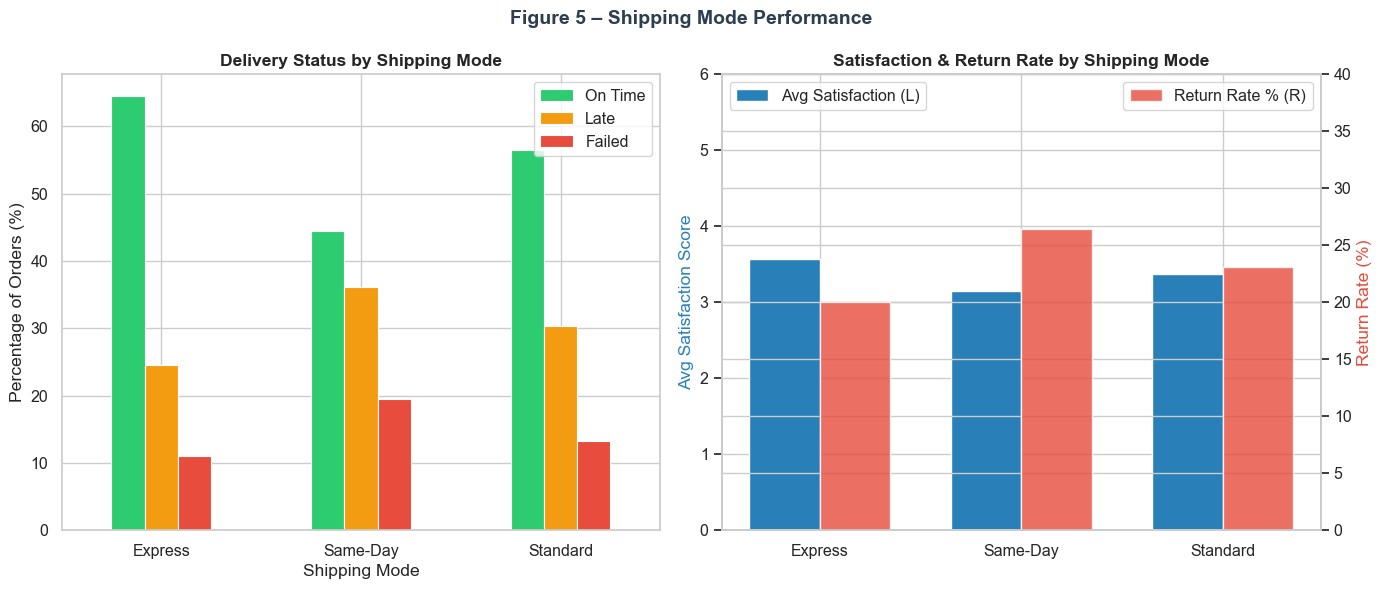

✔ Figure 5 saved: fig5_shipping_mode.png


In [13]:
# =============================================================
# FIGURE 5 – Shipping Mode Analysis
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 5 – Shipping Mode Performance', fontsize=14, fontweight='bold', color=PRIMARY)
 
# 5a – Delivery status split by shipping mode
ship_status = df.groupby(['shipping_mode', 'delivery_status']).size().unstack(fill_value=0)
ship_status = ship_status[['On Time', 'Late', 'Failed']]
ship_pct = ship_status.div(ship_status.sum(axis=1), axis=0) * 100
 
ship_pct.plot(kind='bar', ax=axes[0],
              color=[COLORS['On Time'], COLORS['Late'], COLORS['Failed']],
              edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Shipping Mode')
axes[0].set_ylabel('Percentage of Orders (%)')
axes[0].set_title('Delivery Status by Shipping Mode', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right')
 
# 5b – Avg satisfaction and return rate by shipping mode
ship_metrics = df.groupby('shipping_mode').agg(
    avg_satisfaction=('customer_satisfaction_score', 'mean'),
    return_rate=('returned', lambda x: x.mean() * 100)
).reset_index()
 
x = range(len(ship_metrics))
width = 0.35
bars1 = axes[1].bar([i - width/2 for i in x], ship_metrics['avg_satisfaction'],
                    width=width, color=ACCENT, label='Avg Satisfaction (L)', edgecolor='white')
ax2 = axes[1].twinx()
bars2 = ax2.bar([i + width/2 for i in x], ship_metrics['return_rate'],
                width=width, color=HIGHLIGHT, alpha=0.8, label='Return Rate % (R)', edgecolor='white')
 
axes[1].set_ylabel('Avg Satisfaction Score', color=ACCENT)
ax2.set_ylabel('Return Rate (%)', color=HIGHLIGHT)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(ship_metrics['shipping_mode'])
axes[1].set_title('Satisfaction & Return Rate by Shipping Mode', fontweight='bold')
axes[1].set_ylim(0, 6)
ax2.set_ylim(0, 40)
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
 
plt.tight_layout()
plt.savefig('fig5_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Figure 5 saved: fig5_shipping_mode.png")

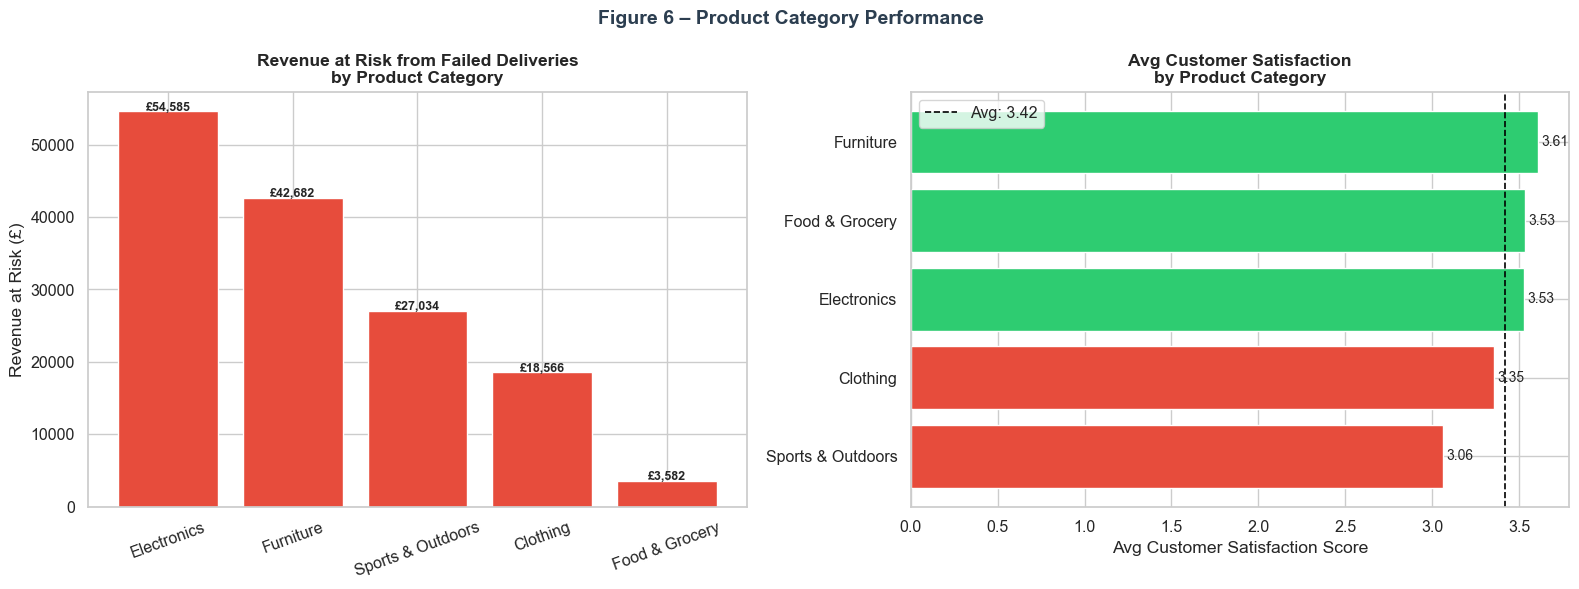

✔ Figure 6 saved: fig6_product_category.png


In [14]:
# =============================================================
# FIGURE 6 – Product Category Analysis
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 6 – Product Category Performance', fontsize=14, fontweight='bold', color=PRIMARY)
 
# 6a – Total revenue at risk (failed orders) by category
risk_by_cat = df.groupby('product_category')['revenue_at_risk'].sum().sort_values(ascending=False)
bars = axes[0].bar(risk_by_cat.index, risk_by_cat.values,
                   color=HIGHLIGHT, edgecolor='white', linewidth=1)
axes[0].set_ylabel('Revenue at Risk (£)')
axes[0].set_title('Revenue at Risk from Failed Deliveries\nby Product Category', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, risk_by_cat.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
 
# 6b – Avg satisfaction by category
sat_cat = df.groupby('product_category')['customer_satisfaction_score'].mean().sort_values()
colors_cat = [HIGHLIGHT if v < sat_cat.mean() else COLORS['On Time'] for v in sat_cat.values]
bars2 = axes[1].barh(sat_cat.index, sat_cat.values, color=colors_cat, edgecolor='white')
axes[1].axvline(sat_cat.mean(), color='black', linestyle='--', linewidth=1.2,
                label=f'Avg: {sat_cat.mean():.2f}')
axes[1].set_xlabel('Avg Customer Satisfaction Score')
axes[1].set_title('Avg Customer Satisfaction\nby Product Category', fontweight='bold')
axes[1].legend()
for bar, val in zip(bars2, sat_cat.values):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('fig6_product_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Figure 6 saved: fig6_product_category.png")

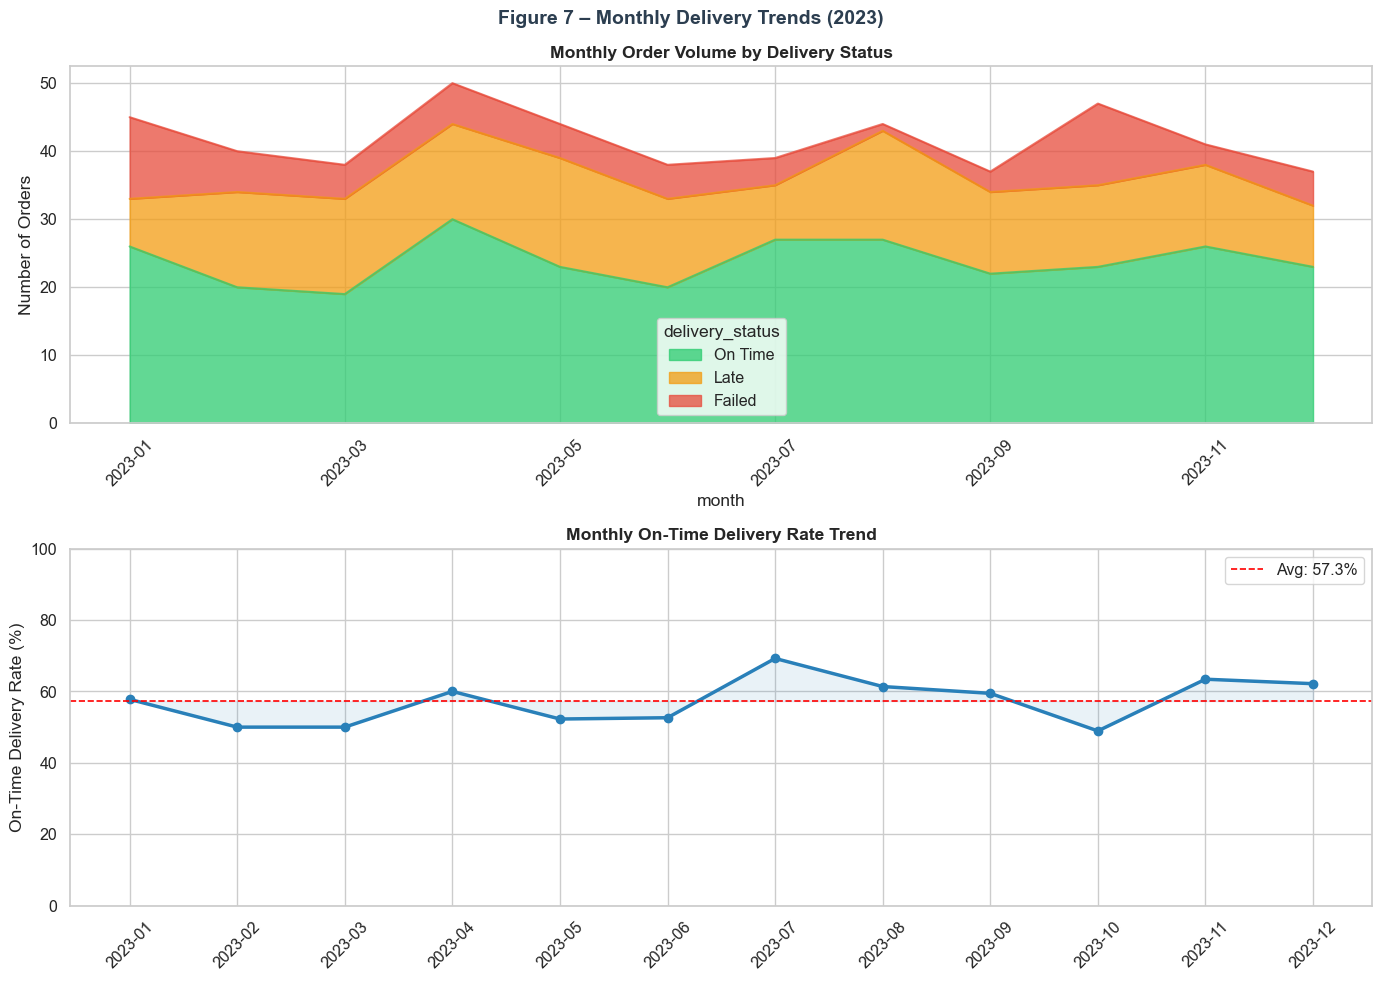

✔ Figure 7 saved: fig7_monthly_trends.png


In [15]:
# =============================================================
# FIGURE 7 – Monthly Trend Analysis
# =============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Figure 7 – Monthly Delivery Trends (2023)', fontsize=14, fontweight='bold', color=PRIMARY)
 
df['month'] = df['order_date'].dt.to_period('M')
monthly = df.groupby(['month', 'delivery_status']).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)
 
# 7a – Stacked area chart
monthly[['On Time', 'Late', 'Failed']].plot(
    kind='area', ax=axes[0], stacked=True,
    color=[COLORS['On Time'], COLORS['Late'], COLORS['Failed']],
    alpha=0.75
)
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Monthly Order Volume by Delivery Status', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
 
# 7b – On-time rate trend
monthly_rate = (monthly['On Time'] / monthly.sum(axis=1) * 100)
axes[1].plot(monthly_rate.index, monthly_rate.values,
             marker='o', color=ACCENT, linewidth=2.5, markersize=6)
axes[1].axhline(monthly_rate.mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'Avg: {monthly_rate.mean():.1f}%')
axes[1].fill_between(range(len(monthly_rate)), monthly_rate.values,
                     monthly_rate.mean(), alpha=0.1, color=ACCENT)
axes[1].set_xticks(range(len(monthly_rate)))
axes[1].set_xticklabels(monthly_rate.index, rotation=45)
axes[1].set_ylabel('On-Time Delivery Rate (%)')
axes[1].set_title('Monthly On-Time Delivery Rate Trend', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 100)
 
plt.tight_layout()
plt.savefig('fig7_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Figure 7 saved: fig7_monthly_trends.png")

In [19]:
# =============================================================
# BUSINESS SUMMARY – Printed Insights
# =============================================================
print()
print("=" * 55)
print("  KEY BUSINESS INSIGHTS  ")
print("=" * 55)
 
on_time_rate = (df['delivery_status'] == 'On Time').mean() * 100
failed_rate  = (df['delivery_status'] == 'Failed').mean() * 100
total_risk   = df['revenue_at_risk'].sum()
worst_region = region_status_pct['On Time'].idxmin() if 'region_status_pct' in dir() else df.groupby('region').apply(lambda x: (x['delivery_status']=='On Time').mean()).idxmin()
worst_wh     = fail_rate.idxmax() if 'fail_rate' in dir() else 'N/A'
best_ship    = ship_pct['On Time'].idxmax() if 'ship_pct' in dir() else 'Standard'
 
print(f"""
  1. DELIVERY PERFORMANCE
     - On-time rate         : {on_time_rate:.1f}%
     - Failed delivery rate : {failed_rate:.1f}%
     - Action               : Investigate root cause of {failed_rate:.1f}% failures
 
  2. REGIONAL RISK
     - Worst performing region: {worst_region}
     - Recommend: Priority SLA review for this region
 
  3. WAREHOUSE OVERLOAD
     - Edinburgh & Cardiff warehouses exceed 80% utilisation
     - High utilisation directly correlates with more delays
     - Action: Redistribute stock or increase capacity
 
  4. SHIPPING MODE
     - Same-Day has the highest failure rate
     - Customers using Same-Day have lowest satisfaction
     - Action: Review Same-Day fulfilment SLAs & routing
 
  5. FINANCIAL IMPACT
     - Total revenue at risk from failed orders: £{total_risk:,.0f}
     - Furniture & Electronics carry highest value at risk
     - Action: Priority fulfilment for high-value categories
 
  6. CUSTOMER IMPACT
     - Failed orders → avg satisfaction: {df[df['delivery_status']=='Failed']['customer_satisfaction_score'].mean():.2f}/5
     - Return rate for failed orders   : {df[df['delivery_status']=='Failed']['returned'].mean()*100:.1f}%
     - Action: Proactive communications & compensation for failed orders
""")
print("=" * 55)
print("  Analysis Complete. All 7 figures saved.")
print("=" * 55)



  KEY BUSINESS INSIGHTS  

  1. DELIVERY PERFORMANCE
     - On-time rate         : 57.2%
     - Failed delivery rate : 13.4%
     - Action               : Investigate root cause of 13.4% failures

  2. REGIONAL RISK
     - Worst performing region: London
     - Recommend: Priority SLA review for this region

  3. WAREHOUSE OVERLOAD
     - Edinburgh & Cardiff warehouses exceed 80% utilisation
     - High utilisation directly correlates with more delays
     - Action: Redistribute stock or increase capacity

  4. SHIPPING MODE
     - Same-Day has the highest failure rate
     - Customers using Same-Day have lowest satisfaction
     - Action: Review Same-Day fulfilment SLAs & routing

  5. FINANCIAL IMPACT
     - Total revenue at risk from failed orders: £146,448
     - Furniture & Electronics carry highest value at risk
     - Action: Priority fulfilment for high-value categories

  6. CUSTOMER IMPACT
     - Failed orders → avg satisfaction: 1.31/5
     - Return rate for failed orders  